Oblaki, iz katerih dežuje, so podani kot četverke `(r0, c0, r1, c1)`, kjer `r0` in `r1` predstavljata vrstico, c1 in c2 pa stolpec. Levi gornji oblak na sliki je opisan z `(0, 1, 3, 5)`.

Slika kaže padavine v enem samem dnevu. Opišemo jih s seznamom takšnih četvork. Za primer s slike je to `[(0, 1, 3, 5), (1, 4, 2, 9), (1, 12, 2, 15), (2, 8, 9, 9), (5, 3, 9, 5), (6, 4, 8, 9), (1, 12, 2, 15), (3, 10, 7, 16), (4, 11, 6, 15), (5, 12, 10, 14), (8, 10, 9, 15)]`.

Oblaki se lahko tudi prekrivajo.

Slika je velikosti 10x16 polj; v nalogah predpostavljamo, da je celotno ozemlje veliko 50x50 polj.

V prvih treh nalogah imamo argument dnevi, ki opisuje padavine v več zaporednih dneh. Ta argument je torej seznam seznamov, kakršen je gornji. Za primer poglejte teste (poiščite self.oblaki). 

Namig: eno od funkcij, napisanih v prvi nalogi, lahko koristno uporabite tudi pri drugi in tretji. Ni pa to obvezno.

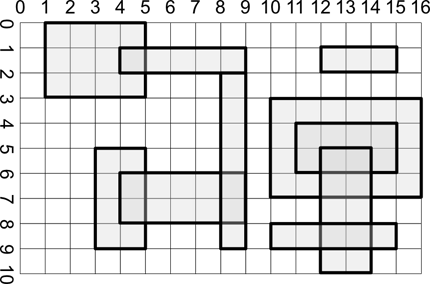

## 1. Zalivanje

Napišite funkcijo `zaliti(oblaki)`, ki prejme seznam četvork s padavinami v enem dnevu, in vrne numpyjevo tabelo velikosti 50x50. Ta vsebuje `True` v celicah, ki ustrezajo poljem, na katera je deževalo iz vsaj enega oblaka (siva polja na sliki) in `False` na poljih, kjer ni (bela polja). Funkcijo po možnosti napišite z eno samo zanko, ne tremi.

Nato napišite funkcijo `zalita(dnevi, meja)`, ki prejme seznam padavin po več dnevih (torej seznam seznamov četvork) in vrne tabelo velikosti 50x50, v kateri je `True` na mestih, ki ustrezajo poljem, na katerih je deževalo vsaj meja dni in `False` na mestih, kjer je deževalo manjkrat. Eleganca rešitve bo cenjena tudi s točkami.

Tabela, ki jo vrne klic `zalita(oblaki, 15)` (na oblakih iz testov), vsebuje  `True` na `(13, 11), (13, 12), (13, 13)`, ker so to edina polja, na katerih je deževalo vsaj v 15 dneh.


### Rešitev

Pripravimo tabelo ničel (`np.zeros`) in povemo, naj bodo shranjene kot `dtype=bool` - torej je to v bistvu tabela `False`-ov. Nato gremo čez vse oblake in ustrezne regije tabele (`[y0:y1, x0:x1]`) postavimo na `True`.

In [1]:
def zaliti(oblaki):
    zaliti = np.zeros((50, 50), dtype=bool)
    for y0, x0, y1, x1 in oblaki:
        zaliti[y0:y1, x0:x1] = True
    return zaliti

Funkcijo `zalita` lahko napišemo tako:

In [2]:
def zalita(dnevi, meja):
    zalitih_dni = np.zeros((50, 50), dtype=int)
    for oblaki in dnevi:
        zalitih_dni += zaliti(oblaki)
    return zalitih_dni >= meja

`zalitih_dni` je tabela, ki vsebuje število zalitih dni. Vanjo prištevamo, kar vrača prejšnja funkcija in na koncu vrnemo tabelo, ki vsebuje `True` tam, kjer je dovolj zalitih dni.

Krajša rešitev sestavi tridimenzionalno tabelo - prva dimenzija so dnevi, ostali dve sta 50x50. Tabela vsebuje tabele, kot jih vrača prejšnja funkcija "zložene" ena za drugo.

```
np.array([zaliti(oblaki) for oblaki in dnevi])
```

To seštejemo po osi 0,

```
np.sum(np.array([zaliti(oblaki) for oblaki in dnevi]), axis=0)
```

Potem pa le še pogledamo, kje je ta vsota večja ali enaka meji.

In [3]:
def zalita(dnevi, meja):
    return np.sum(np.array([zaliti(oblaki) for oblaki in dnevi]), axis=0) >= meja

## 2. Poročilo

Napišite funkcijo `porocilo(dnevi, ime_datoteke)`, ki prejme seznam padavin prek nekega časovnega obdobja. Za vsak dan prešteje, koliko polj je bilo zalitih ter podatke o številu oblakov in številu zalitih polj shrani v datoteko natančno v spodnji obliki. **Četudi isto polje zalije več oblakov, ga štejte le enkrat.**

(Dan je izpisan na dve mesti, število oblakov in zalitih polj pa na 8.)

### Rešitev

In [4]:
def porocilo(dnevi, ime_datoteke):
    f = open(ime_datoteke, "w", encoding="utf-8")
    f.write(f"{'Oblakov':>14}{'Zalitih':>8}\n")
    f.write("-" * 22 + "\n")
    for i, dan in enumerate(dnevi, start=1):
        f.write(f"Dan {i:2}{len(dan):8}{np.sum(zaliti(dan)):8}\n")
    f.close()

Datoteke se, čisto po bontonu, odpira malo drugače, vendar se v te (za Python specifične) podrobnosti nismo preveč spuščali niti na predavanjih, še manj se bomo tule.

Za nalogo je pomembna predvsem zadnja vrstica, v kateri oblikujemo niz: število dneva (`i`) izpišemo na dve mesti, število oblakov (`len(dan)`) in število zalitih polj na osem. Število zalitih polj dobimo preprosto tako, da seštejemo vse elemente tabele, ki jo vrne funkcija `zaliti(dan)`, `np.sum(zaliti(dan))`. 

Eno vrstico prej imamo zanimivo zanko: ne le `for dan in dnevi`, temveč `for i, dan in enumerate(dnevi, start=1)`, saj potrebujemo tudi zaporedno številko dneva (ker jo moramo pač izpisati), `start=1` pa je potreben zato, da `enumerate` šteje od `1` in ne od `0`. Če za ta argument ne vemo, pač pišemo `for i, dan in enumerate(dnevi)`, potem pa namesto `i` izpisujemo `i + 1`.

Če gremo še dve vrstici višje: tam izpišemo prvo vrstico, ("Oblakov" in "Zalitih") na ustrezno število mest, potem pa še primerno število minusov.

## 3. Dolžina suše

Napišite funkcijo `dolzina_suse(dnevi, vrstica, stolpec)`, ki za podano polje (vrstica, stolpec) vrne najdaljše število zaporednih dni brez dežja. (Vrstica in stolpec sta podana tako, da ima gornje levo polje koordinate 0, 0).

Za primere iz testov je na polju (5, 15) deževalo na dnevih označenih z x v naslednjem zaporedju: ..X..XXX...XX.X.....X. Najdaljše obdobje suše je trajalo 5 dni (saj imamo največ pet zaporednih pik).

### Rešitev

Hraniti moramo dolžino najdaljše in dolžino trenutne suše.

Za vsak dan pokličemo funkcojo iz prve naloge in preverimo, ali je podano polje med zalitimi. Če je, prekinemo trenutno sušo. Če ni, podaljšamo trenutno sušo za en dan in preverimo, če je s tem presegla (doslej) najdaljšo sušo, kar si seveda zapomnimo.

In [5]:
def dolzina_suse(dnevi, y, x):
    najdaljsa_susa = 0
    trenutna_susa = 0
    for dan in dnevi:
        if zaliti(dan)[y, x]:
            trenutna_susa = 0
        else:
            trenutna_susa += 1
            if trenutna_susa > najdaljsa_susa:
                najdaljsa_susa = trenutna_susa
    return suse

## 4. Naj oblak

Tole nalogo se da rešiti na veliko načinov: lahko se je lotite z numpyjem (s katerim gre prav elegantno, a zahteva malo domiselnosti), s slovarji ali kar z običajnimi zankami in seznami.

Neko poletje se je izkazalo, da se oblaki niso nikoli prekrivali, da so cele dneve mirovali in da je na vsako polno uro deževalo iz natančno enega oblaka. Nekdo vsako uro shrani v seznam koordinati enega od polj, na katerega dežuje (deževalo je tudi na druga polja, saj so oblaki večji; zabeleženo je eno izmed polj pod oblakom, iz katerega dežuje).

Napišite funkcijo `naj_oblak(oblaki, padavine)`, ki prejme seznam oblakov (ki se ne prekrivajo) in seznam polj, na katerih je bil zaznan dež. Funkcija naj vrne koordinate oblaka, iz katerega je največkrat deževalo. Če je enako deževnih oblakov več, sme funkcija vrniti poljubnega med njimi.

Klic

```
naj_oblak([(0, 1, 3, 5), (6, 4, 8, 9), (3, 10, 7, 16), (1, 12, 2, 15)],
          [(1, 3), (6, 8), (4, 11), (1, 13), (6, 5), (1, 3), (7, 7)])
```

vrne `(6, 4, 8, 9)`, ker je največkrat (trikrat) deževalo iz tega oblaka (pod njim so polja `(6, 8), (6, 5) in (7, 7)`).

### Rešitev

Očitna rešitev je, da gremo čez vse oblake (prvi argument), za vsakega nato čez vse padavine (drugi argument) in štejemo, kolikokrat je padalo iz tega oblaka. Če je ta oblak rekorder, si to zapomnimo.

In [7]:
def naj_oblak(oblaki, padavine):
    naj_pad = 0
    for i, (y0, x0, y1, x1) in enumerate(oblaki):
        iz_tega_oblaka = 0
        for y, x in padavine:
            if y0 <= y < y1 and x0 <= x < x1:
                iz_tega_oblaka += 1
        if iz_tega_oblaka > naj_pad:
            naj_pad = iz_tega_oblaka
            naj_oblak = (y0, x0, y1, x1)
    return naj_oblak

Zdaj pa bolj zanimiva rešitev.

In [9]:
def naj_oblak(oblaki, padavine):
    pripadnost = np.full((50, 50), -1, dtype=int)
    for i, (y0, x0, y1, x1) in enumerate(oblaki):
        pripadnost[y0:y1, x0:x1] = i
        
    padavin = np.zeros(len(oblaki), dtype=int)
    for y, x in padavine:
        padavin[pripadnost[y, x]] += 1

    return oblaki[np.argmax(padavin)]

Tule oblake oštevilčimo. Naloga pravi, da se ne prekrivajo. Tabela `pripadnost` je velikosti 50x50 in za vsako polje vsebuje zaporedno številko oblaka, ki prekriva to polje, oziroma -1, če nad poljem ni nobenega oblaka (to je sicer bolj zaradi higiene - ker na ta polja ne more deževati, bi lahko bilo v njih napisano karkoli). To si pripravimo v prvem delu funkcije.

Nato pripravimo tabelo `padavin`, ki ima toliko elementov, kolikor je oblakov; štela bo količino padavin iz vsakega oblaka. Gremo čez zabeležene padavine `(y, x)`, pogledamo, iz katerega oblaka padajo (`pripadnost[y, x]`) in povečamo število padavin iz tega oblaka (`padavin[pripadnost[y, x]] += 1`).

Na koncu z `np.argmax(padavin)` poiščemo indeks oblaka z največ padavinami in vrnemo koordinate ustreznega oblaka.